In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Data_Science_Project/Los Angeles/listings_detailed.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,777451666060243581,https://www.airbnb.com/rooms/777451666060243581,20230307175359,2023-03-07,city scrape,Family oriented home,Relax with the whole family at this peaceful p...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,490709958,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
1,698097753730921190,https://www.airbnb.com/rooms/698097753730921190,20230307175359,2023-03-07,city scrape,方便易居驿站,NaN,NaN,https://a0.muscache.com/pictures/d5afff58-d576...,444692513,...,5.00,5.00,4.40,NaN,f,4,0,4,0,0.86
2,13063118,https://www.airbnb.com/rooms/13063118,20230307175359,2023-03-07,city scrape,TERRANEA OCEANFRNT 1BR CASITA -203 RSRT AMENIT...,LOCATION! Luxury upstairs Oceanside Casita gue...,No need to fly away from Los Angeles for a get...,https://a0.muscache.com/pictures/6227287c-7073...,41736985,...,4.96,4.92,4.83,NaN,f,10,5,5,0,0.64
3,39337076,https://www.airbnb.com/rooms/39337076,20230307175359,2023-03-07,city scrape,Brand New Duplex Near World Cruise Center,Welcome to our new cozy duplex!<br /><br />Loc...,"Our property is close to downtown San Pedro, t...",https://a0.muscache.com/pictures/miso/Hosting-...,208375458,...,4.86,4.66,4.82,NaN,t,4,0,4,0,1.09
4,13077628,https://www.airbnb.com/rooms/13077628,20230307175359,2023-03-07,city scrape,Zuma Malibu Retreat,Our Private 16 Acre Malibu Retreat is located ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,4182067,...,4.79,4.64,4.36,STR21-0228,f,1,1,0,0,0.18


In [4]:
df.columns
df.isna().sum()

,0
id,0
listing_url,0
scrape_id,0
last_scraped,0
source,0
...,...
calculated_host_listings_count,0
calculated_host_listings_count_entire_homes,0
calculated_host_listings_count_private_rooms,0
calculated_host_listings_count_shared_rooms,0


In [5]:
'''
Host Characteristics:

host_is_superhost: A primary indicator of host quality.

host_response_rate / host_acceptance_rate: Measures of professional engagement.

host_identity_verified: Trust factor.

host_listings_count: Distinguishes between individual hosts and professional management companies.

host_since: Can be used to calculate "host tenure" (years of experience).


Listing Components:

room_type : Fundamental price drivers.

accommodates, bedrooms, beds, bathrooms_text: Physical capacity of the unit.

amenities: You can count the number of amenities or look for specific high-value ones (e.g., "Wifi," "Pool").

neighbourhood_cleansed: Essential for comparing across cities.


Review & Quality Metrics:

number_of_reviews: Popularity and social proof.

instant_bookable: Ease of booking.


Target Variable:

price: This is what you are predicting or estimating.

'''

'\nHost Characteristics:\n\nhost_is_superhost: A primary indicator of host quality.\n\nhost_response_rate / host_acceptance_rate: Measures of professional engagement.\n\nhost_identity_verified: Trust factor.\n\nhost_listings_count: Distinguishes between individual hosts and professional management companies.\n\nhost_since: Can be used to calculate "host tenure" (years of experience).\n\n\nListing Components:\n\nroom_type : Fundamental price drivers.\n\naccommodates, bedrooms, beds, bathrooms_text: Physical capacity of the unit.\n\namenities: You can count the number of amenities or look for specific high-value ones (e.g., "Wifi," "Pool").\n\nneighbourhood_cleansed: Essential for comparing across cities.\n\n\nReview & Quality Metrics:\n\nnumber_of_reviews: Popularity and social proof.\n\ninstant_bookable: Ease of booking.\n\n\nTarget Variable:\n\nprice: This is what you are predicting or estimating.\n\n'

In [6]:
cols_to_keep = [
    'host_is_superhost',
    'host_response_rate',
    'host_acceptance_rate',
    'host_identity_verified',
    'host_listings_count',
    'host_since',
    'room_type',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms_text',
    'amenities',
    'neighbourhood_cleansed',
    'number_of_reviews',
    'instant_bookable',
    'price'
]

In [7]:
la_df = df[cols_to_keep].copy()
la_df.head()

,host_is_superhost,host_response_rate,host_acceptance_rate,host_identity_verified,host_listings_count,host_since,room_type,accommodates,bedrooms,beds,bathrooms_text,amenities,neighbourhood_cleansed,number_of_reviews,instant_bookable,price
0,f,100%,0%,t,1.0,2022-12-08,Private room,7,4.0,3.0,3.5 baths,"[""Wifi"", ""Exercise equipment"", ""Carbon monoxid...",Castaic Canyons,0,f,$399.00
1,t,100%,100%,t,4.0,2022-02-12,Private room,2,1.0,1.0,1 shared bath,"[""Bed linens"", ""Wifi"", ""Carbon monoxide alarm""...",Pomona,5,f,$46.00
2,f,100%,86%,t,15.0,2015-08-17,Private room,3,1.0,1.0,1 bath,"[""Shared hot tub"", ""Wifi"", ""Refrigerator"", ""Gy...",Rancho Palos Verdes,53,f,$408.00
3,t,100%,99%,t,4.0,2018-08-09,Private room,2,1.0,1.0,1 shared bath,"[""Smoke alarm"", ""Freezer"", ""Shampoo"", ""Park vi...",Rancho Palos Verdes,44,t,$80.00
4,f,100%,NaN,t,1.0,2012-11-18,Entire home/apt,8,3.0,4.0,2 baths,"[""Sonos sound system"", ""Central heating"", ""Smo...",Malibu,15,f,"$2,138.00"


In [8]:
#host_is_superhost: * Action: Usually, if this is null, the host is not a Superhost. You can safely fill these with "f" (false).
la_df['host_is_superhost'] = la_df['host_is_superhost'].fillna('f')

In [9]:
'''
host_response_rate & host_acceptance_rate:
-->
second "flag" column (e.g., has_response_rate: 0 or 1) to see
if not having a rate impacts price.

why: because these rates can give severe advantage to someone with 95% rate over
someone with 85% rate.

'''

la_df['has_response_rate'] = la_df['host_response_rate'].notna().astype(int)
la_df['has_acceptance_rate'] = la_df['host_acceptance_rate'].notna().astype(int)


In [10]:
la_df.drop(columns=['host_response_rate', 'host_acceptance_rate'], inplace=True)

In [11]:
la_df.isna().sum()

,0
host_is_superhost,0
host_identity_verified,2
host_listings_count,2
host_since,2
room_type,0
accommodates,0
bedrooms,3619
beds,597
bathrooms_text,41
amenities,0


In [12]:
la_df.head()

,host_is_superhost,host_identity_verified,host_listings_count,host_since,room_type,accommodates,bedrooms,beds,bathrooms_text,amenities,neighbourhood_cleansed,number_of_reviews,instant_bookable,price,has_response_rate,has_acceptance_rate
0,f,t,1.0,2022-12-08,Private room,7,4.0,3.0,3.5 baths,"[""Wifi"", ""Exercise equipment"", ""Carbon monoxid...",Castaic Canyons,0,f,$399.00,1,1
1,t,t,4.0,2022-02-12,Private room,2,1.0,1.0,1 shared bath,"[""Bed linens"", ""Wifi"", ""Carbon monoxide alarm""...",Pomona,5,f,$46.00,1,1
2,f,t,15.0,2015-08-17,Private room,3,1.0,1.0,1 bath,"[""Shared hot tub"", ""Wifi"", ""Refrigerator"", ""Gy...",Rancho Palos Verdes,53,f,$408.00,1,1
3,t,t,4.0,2018-08-09,Private room,2,1.0,1.0,1 shared bath,"[""Smoke alarm"", ""Freezer"", ""Shampoo"", ""Park vi...",Rancho Palos Verdes,44,t,$80.00,1,1
4,f,t,1.0,2012-11-18,Entire home/apt,8,3.0,4.0,2 baths,"[""Sonos sound system"", ""Central heating"", ""Smo...",Malibu,15,f,"$2,138.00",1,0


In [13]:
'''
Action: Use the accommodates value to estimate.
If accommodates is 1 or 2 and bedrooms is null, it's safe to impute a 1.
'''
import numpy as np

# Logic for Bedrooms: All Nulls become 1 (treating Studios as 1-bed units)
la_df['bedrooms'] = la_df['bedrooms'].fillna(1)

# Logic for Beds: If Null, use half of 'accommodates' (rounded up)
# Example: Accommodates 1 or 2 -> 1 bed. Accommodates 3 or 4 -> 2 beds.
la_df['beds'] = la_df['beds'].fillna((la_df['accommodates'] / 2).apply(np.ceil))


In [14]:
la_df.isna().sum()

,0
host_is_superhost,0
host_identity_verified,2
host_listings_count,2
host_since,2
room_type,0
accommodates,0
bedrooms,0
beds,0
bathrooms_text,41
amenities,0


In [15]:
# now just remove all rows with nulls

la_df.dropna(inplace=True)

In [16]:
la_df.isna().sum()

,0
host_is_superhost,0
host_identity_verified,0
host_listings_count,0
host_since,0
room_type,0
accommodates,0
bedrooms,0
beds,0
bathrooms_text,0
amenities,0


In [17]:
la_df.head()

,host_is_superhost,host_identity_verified,host_listings_count,host_since,room_type,accommodates,bedrooms,beds,bathrooms_text,amenities,neighbourhood_cleansed,number_of_reviews,instant_bookable,price,has_response_rate,has_acceptance_rate
0,f,t,1.0,2022-12-08,Private room,7,4.0,3.0,3.5 baths,"[""Wifi"", ""Exercise equipment"", ""Carbon monoxid...",Castaic Canyons,0,f,$399.00,1,1
1,t,t,4.0,2022-02-12,Private room,2,1.0,1.0,1 shared bath,"[""Bed linens"", ""Wifi"", ""Carbon monoxide alarm""...",Pomona,5,f,$46.00,1,1
2,f,t,15.0,2015-08-17,Private room,3,1.0,1.0,1 bath,"[""Shared hot tub"", ""Wifi"", ""Refrigerator"", ""Gy...",Rancho Palos Verdes,53,f,$408.00,1,1
3,t,t,4.0,2018-08-09,Private room,2,1.0,1.0,1 shared bath,"[""Smoke alarm"", ""Freezer"", ""Shampoo"", ""Park vi...",Rancho Palos Verdes,44,t,$80.00,1,1
4,f,t,1.0,2012-11-18,Entire home/apt,8,3.0,4.0,2 baths,"[""Sonos sound system"", ""Central heating"", ""Smo...",Malibu,15,f,"$2,138.00",1,0


In [18]:
#for amenities --> just count the number of amenities and make a column named --> amenities_count

la_df['amenities_count'] = la_df['amenities'].str.count(',') + 1
la_df.drop(columns=['amenities'], inplace=True)

In [19]:
la_df.head()

,host_is_superhost,host_identity_verified,host_listings_count,host_since,room_type,accommodates,bedrooms,beds,bathrooms_text,neighbourhood_cleansed,number_of_reviews,instant_bookable,price,has_response_rate,has_acceptance_rate,amenities_count
0,f,t,1.0,2022-12-08,Private room,7,4.0,3.0,3.5 baths,Castaic Canyons,0,f,$399.00,1,1,10
1,t,t,4.0,2022-02-12,Private room,2,1.0,1.0,1 shared bath,Pomona,5,f,$46.00,1,1,15
2,f,t,15.0,2015-08-17,Private room,3,1.0,1.0,1 bath,Rancho Palos Verdes,53,f,$408.00,1,1,19
3,t,t,4.0,2018-08-09,Private room,2,1.0,1.0,1 shared bath,Rancho Palos Verdes,44,t,$80.00,1,1,58
4,f,t,1.0,2012-11-18,Entire home/apt,8,3.0,4.0,2 baths,Malibu,15,f,"$2,138.00",1,0,61


In [20]:
#converting host_is_superhost, host_identity_verified, instant_bookable
la_df['host_is_superhost'] = la_df['host_is_superhost'].map({'t': 1, '  f': 0  ,'f': 0})
la_df['instant_bookable'] = la_df['instant_bookable'].map({'t': 1, 'f': 0})

In [21]:
#look for all uniques in host_identity verified
la_df['host_identity_verified'].unique()
#now convert
la_df['host_identity_verified'] = la_df['host_identity_verified'].map({'t': 1, 'f': 0})


In [22]:
la_df.head()

,host_is_superhost,host_identity_verified,host_listings_count,host_since,room_type,accommodates,bedrooms,beds,bathrooms_text,neighbourhood_cleansed,number_of_reviews,instant_bookable,price,has_response_rate,has_acceptance_rate,amenities_count
0,0,1,1.0,2022-12-08,Private room,7,4.0,3.0,3.5 baths,Castaic Canyons,0,0,$399.00,1,1,10
1,1,1,4.0,2022-02-12,Private room,2,1.0,1.0,1 shared bath,Pomona,5,0,$46.00,1,1,15
2,0,1,15.0,2015-08-17,Private room,3,1.0,1.0,1 bath,Rancho Palos Verdes,53,0,$408.00,1,1,19
3,1,1,4.0,2018-08-09,Private room,2,1.0,1.0,1 shared bath,Rancho Palos Verdes,44,1,$80.00,1,1,58
4,0,1,1.0,2012-11-18,Entire home/apt,8,3.0,4.0,2 baths,Malibu,15,0,"$2,138.00",1,0,61


In [23]:
#adjust the host_since --> for actual numerical value --> in years
import pandas as pd
from datetime import datetime

la_df['host_since'] = la_df['host_since'].astype(str).str[:10]

la_df['host_since'] = pd.to_datetime(la_df['host_since'], errors='coerce')

reference_date = pd.to_datetime('2026-04-11')
la_df['host_since'] = (reference_date - la_df['host_since']).dt.days / 365.25



In [24]:
la_df.head()

,host_is_superhost,host_identity_verified,host_listings_count,host_since,room_type,accommodates,bedrooms,beds,bathrooms_text,neighbourhood_cleansed,number_of_reviews,instant_bookable,price,has_response_rate,has_acceptance_rate,amenities_count
0,0,1,1.0,3.340178,Private room,7,4.0,3.0,3.5 baths,Castaic Canyons,0,0,$399.00,1,1,10
1,1,1,4.0,4.158795,Private room,2,1.0,1.0,1 shared bath,Pomona,5,0,$46.00,1,1,15
2,0,1,15.0,10.650240,Private room,3,1.0,1.0,1 bath,Rancho Palos Verdes,53,0,$408.00,1,1,19
3,1,1,4.0,7.671458,Private room,2,1.0,1.0,1 shared bath,Rancho Palos Verdes,44,1,$80.00,1,1,58
4,0,1,1.0,13.393566,Entire home/apt,8,3.0,4.0,2 baths,Malibu,15,0,"$2,138.00",1,0,61


In [25]:
#chnage the room_type to be numerical --> (One-Hot Encoding) to avoid traps with 0 and 5 being numerically different
# nyc_df['room_type'].unique()

# This creates the room_type_Private room, etc. as 1s and 0s
la_df = pd.get_dummies(la_df, columns=['room_type'], dtype=int)



In [26]:
la_df.isna().sum()

,0
host_is_superhost,0
host_identity_verified,0
host_listings_count,0
host_since,0
accommodates,0
bedrooms,0
beds,0
bathrooms_text,0
neighbourhood_cleansed,0
number_of_reviews,0


In [27]:
#fix the bathrooms text

# 1. Create 'bathrooms' column by grabbing the first number found in the text
# This handles "3.5 baths", "1 bath", "11.5 shared baths", etc.
la_df['bathrooms'] = la_df['bathrooms_text'].str.extract('(\d+\.?\d*)').astype(float)

# 2. Fix the "Half-bath" cases (since they have no number, extract makes them NaN)
# If the text says "half", we just set the number to 0.5
la_df.loc[la_df['bathrooms_text'].str.contains('half', case=False, na=False), 'bathrooms'] = 0.5

# 3. Create 'is_shared_bath' (1 if it's shared, 0 if it's private)
# This is a simple "True/False" check converted to "1/0"
la_df['is_shared_bath'] = la_df['bathrooms_text'].str.contains('shared', case=False, na=False).astype(int)

# 4. Fill any remaining blanks with 1 (the most common bathroom count)
la_df['bathrooms'] = la_df['bathrooms'].fillna(1)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_14823/1761359130.py:5: SyntaxWarning: invalid escape sequence '\d'
  la_df['bathrooms'] = la_df['bathrooms_text'].str.extract('(\d+\.?\d*)').astype(float)


In [28]:
la_df.drop(columns=['bathrooms_text'], inplace=True)

In [29]:
la_df.isna().sum()

,0
host_is_superhost,0
host_identity_verified,0
host_listings_count,0
host_since,0
accommodates,0
bedrooms,0
beds,0
neighbourhood_cleansed,0
number_of_reviews,0
instant_bookable,0


In [30]:
la_df.head()

,host_is_superhost,host_identity_verified,host_listings_count,host_since,accommodates,bedrooms,beds,neighbourhood_cleansed,number_of_reviews,instant_bookable,price,has_response_rate,has_acceptance_rate,amenities_count,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,bathrooms,is_shared_bath
0,0,1,1.0,3.340178,7,4.0,3.0,Castaic Canyons,0,0,$399.00,1,1,10,0,0,1,0,3.5,0
1,1,1,4.0,4.158795,2,1.0,1.0,Pomona,5,0,$46.00,1,1,15,0,0,1,0,1.0,1
2,0,1,15.0,10.650240,3,1.0,1.0,Rancho Palos Verdes,53,0,$408.00,1,1,19,0,0,1,0,1.0,0
3,1,1,4.0,7.671458,2,1.0,1.0,Rancho Palos Verdes,44,1,$80.00,1,1,58,0,0,1,0,1.0,1
4,0,1,1.0,13.393566,8,3.0,4.0,Malibu,15,0,"$2,138.00",1,0,61,1,0,0,0,2.0,0


In [31]:
#fix the neighbourhood_cleansed
la_df['neighbourhood_cleansed'].unique()

array(['Castaic Canyons', 'Pomona', 'Rancho Palos Verdes', 'Malibu',
       'San Pedro', 'Diamond Bar', 'West Compton',
       'Northeast Antelope Valley', 'West Carson',
       'Unincorporated Santa Susana Mountains', 'Lomita', 'Whittier',
       'Norwalk', 'Rolling Hills Estates', 'Lancaster', 'Artesia',
       'Bellflower', 'La Puente', 'Gardena', 'Lynwood', 'Downey',
       'Palmdale', 'Southeast Antelope Valley',
       'Unincorporated Santa Monica Mountains', 'San Fernando',
       'Santa Clarita', 'Walnut', 'Bell Gardens', 'Carson',
       'Stevenson Ranch', 'Palos Verdes Estates', 'Acton', 'Quartz Hill',
       'Porter Ranch', 'Granada Hills', 'Hawaiian Gardens',
       'Vermont Knolls', 'Northridge', 'Hacienda Heights', 'Torrance',
       'Rowland Heights', 'South San Gabriel', 'Montebello',
       'West Covina', 'Monterey Park', 'Vermont Square',
       'Florence-Firestone', 'Agoura Hills', 'Vernon', 'Brentwood',
       'Pacific Palisades', 'Hawthorne', 'La Verne', 'Claremont

In [32]:
neighborhood_groups = {
    'Coastal': [
        'Malibu', 'Santa Monica', 'Venice', 'Pacific Palisades', 'Manhattan Beach',
        'Hermosa Beach', 'Marina del Rey', 'Playa del Rey', 'Avalon', 'Rancho Palos Verdes',
        'San Pedro', 'Palos Verdes Estates', 'Rolling Hills Estates', 'Rolling Hills',
        'El Segundo', 'Redondo Beach', 'Del Aire', 'Unincorporated Catalina Island'
    ],
    'Westside_Hollywood': [
        'Beverly Hills', 'Bel-Air', 'West Hollywood', 'Hollywood Hills', 'Hollywood Hills West',
        'Brentwood', 'Westwood', 'Culver City', 'Beverly Grove', 'Mar Vista', 'Sawtelle',
        'Cheviot Hills', 'Beverly Crest', 'Pico-Robertson', 'Pacific Palisades', 'Century City',
        'Rancho Park', 'Cheviot Hills', 'Windsor Square', 'Hancock Park', 'Beverlywood',
        'Bel-Air', 'Universal City', 'West Los Angeles', 'Del Rey', 'Playa Vista'
    ],
    'Central_LA': [
        'Downtown', 'Koreatown', 'Hollywood', 'Silver Lake', 'Echo Park', 'Mid-Wilshire',
        'Westlake', 'Los Feliz', 'Chinatown', 'Boyle Heights', 'East Hollywood', 'Carthay',
        'Pico-Union', 'Harvard Heights', 'Larchmont', 'Arlington Heights', 'University Park',
        'West Adams', 'Jefferson Park', 'Exposition Park', 'Adams-Normandie', 'Elysian Valley',
        'Highland Park', 'Eagle Rock', 'Atwater Village', 'Glassell Park', 'Mount Washington',
        'Cypress Park', 'Elysian Park', 'Montecito Heights', 'Lincoln Heights', 'Historic South-Central'
    ],
    'The_Valley': [
        'Sherman Oaks', 'Encino', 'Northridge', 'Woodland Hills', 'Van Nuys', 'Burbank',
        'Studio City', 'Reseda', 'Canoga Park', 'North Hollywood', 'Valley Village',
        'Valley Glen', 'Van Nuys', 'Tarzana', 'Chatsworth', 'North Hills', 'Granada Hills',
        'Porter Ranch', 'San Fernando', 'Pacoima', 'Sylmar', 'Mission Hills', 'Arleta',
        'Panorama City', 'Sun Valley', 'Sunland', 'Tujunga', 'Shadow Hills', 'Lake Balboa',
        'Winnetka', 'West Hills', 'Toluca Lake', 'Porter Ranch', 'Lake View Terrace',
        'Sepulveda Basin', 'Tujunga Canyons'
    ],
    'South_LA_Harbor': [
        'Long Beach', 'Torrance', 'San Pedro', 'Carson', 'Gardena', 'Inglewood',
        'Hawthorne', 'Compton', 'Watts', 'Lennox', 'Lawndale', 'Lomita', 'Harbor City',
        'Wilmington', 'Harbor Gateway', 'West Carson', 'Athens', 'Westmont', 'Florence',
        'Florence-Firestone', 'Green Meadows', 'South Park', 'Central-Alameda', 'Vermont Square',
        'Vermont Vista', 'Vermont Knolls', 'Vermont-Slauson', 'Hyde Park', 'Leimert Park',
        'View Park-Windsor Hills', 'Baldwin Hills/Crenshaw', 'Ladera Heights', 'Gramercy Park',
        'Manchester Square', 'Chesterfield Square', 'Harvard Park', 'Walnut Park', 'Lynwood',
        'South Gate', 'Cudahy', 'Bell', 'Bell Gardens', 'Huntington Park', 'Vernon', 'Commerce',
        'Signal Hill', 'Lakewood', 'Bellflower', 'Norwalk', 'Paramount', 'Cerritos', 'Artesia',
        'Hawaiian Gardens', 'Alondra Park', 'Willowbrook', 'Rancho Dominguez'
    ],
    'East_LA_SGV': [
        'Pasadena', 'Alhambra', 'Monterey Park', 'East Los Angeles', 'El Monte',
        'West Covina', 'Diamond Bar', 'Glendale', 'South Pasadena', 'San Marino',
        'San Gabriel', 'Temple City', 'Arcadia', 'Sierra Madre', 'Monrovia', 'Duarte',
        'Azusa', 'Glendora', 'Claremont', 'La Verne', 'San Dimas', 'Pomona', 'Walnut',
        'Rowland Heights', 'Hacienda Heights', 'La Puente', 'Valinda', 'Bassett',
        'West Puente Valley', 'Avocado Heights', 'South El Monte', 'Rosemead', 'Pico Rivera',
        'Whittier', 'Montebello', 'South San Gabriel', 'East San Gabriel', 'Mayflower Village',
        'Irwindale', 'Baldwin Park', 'Citrus', 'Charter Oak', 'South San Jose Hills',
        'South Whittier', 'East Whittier', 'North Whittier', 'La Mirada', 'Santa Fe Springs',
        'Downey', 'La Habra Heights', 'Walnut Park', 'East Pasadena', 'South Whittier',
        'Altadena', 'La Crescenta-Montrose', 'La Canada Flintridge'
    ],
    'North_County': [
        'Santa Clarita', 'Lancaster', 'Palmdale', 'Castaic', 'Acton', 'Agua Dulce',
        'Stevenson Ranch', 'Val Verde', 'Castaic Canyons', 'Hasley Canyon', 'Quartz Hill',
        'Lake Los Angeles', 'Sun Village', 'Littlerock', 'Elizabeth Lake', 'Lake Hughes',
        'Leona Valley', 'Green Valley', 'Desert View Highlands', 'Northwest Antelope Valley',
        'Northeast Antelope Valley', 'Southeast Antelope Valley', 'Northwest Palmdale',
        'Agoura Hills', 'Calabasas', 'Hidden Hills', 'Westlake Village', 'Topanga',
        'Unincorporated Santa Monica Mountains', 'Unincorporated Santa Susana Mountains',
        'Ridge Route', 'Angeles Crest', 'Lopez/Kagel Canyons', 'Vincent'
    ]
}

In [33]:
# Create the flat mapping dictionary
flat_map = {nb: region for region, nbs in neighborhood_groups.items() for nb in nbs}

# Map the column
la_df['region'] = la_df['neighbourhood_cleansed'].map(flat_map).fillna('Other_Residential')

# Final One-Hot Encoding
la_df = pd.get_dummies(la_df, columns=['region'], drop_first=True, dtype=int)

In [34]:
la_df.drop(columns=['neighbourhood_cleansed'], inplace=True)

In [35]:
la_df.head()

,host_is_superhost,host_identity_verified,host_listings_count,host_since,accommodates,bedrooms,beds,number_of_reviews,instant_bookable,price,...,room_type_Shared room,bathrooms,is_shared_bath,region_Coastal,region_East_LA_SGV,region_North_County,region_Other_Residential,region_South_LA_Harbor,region_The_Valley,region_Westside_Hollywood
0,0,1,1.0,3.340178,7,4.0,3.0,0,0,$399.00,...,0,3.5,0,0,0,1,0,0,0,0
1,1,1,4.0,4.158795,2,1.0,1.0,5,0,$46.00,...,0,1.0,1,0,1,0,0,0,0,0
2,0,1,15.0,10.650240,3,1.0,1.0,53,0,$408.00,...,0,1.0,0,1,0,0,0,0,0,0
3,1,1,4.0,7.671458,2,1.0,1.0,44,1,$80.00,...,0,1.0,1,1,0,0,0,0,0,0
4,0,1,1.0,13.393566,8,3.0,4.0,15,0,"$2,138.00",...,0,2.0,0,1,0,0,0,0,0,0


In [36]:
la_df.columns

Index(['host_is_superhost', 'host_identity_verified', 'host_listings_count',
       'host_since', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews',
       'instant_bookable', 'price', 'has_response_rate', 'has_acceptance_rate',
       'amenities_count', 'room_type_Entire home/apt', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room', 'bathrooms',
       'is_shared_bath', 'region_Coastal', 'region_East_LA_SGV',
       'region_North_County', 'region_Other_Residential',
       'region_South_LA_Harbor', 'region_The_Valley',
       'region_Westside_Hollywood'],
      dtype='object')

B. MLE (Maximum Likelihood Estimation)

Research Question: What probability distribution best describes Airbnb prices in Los Angeles, and what are the maximum likelihood estimates of its parameters?

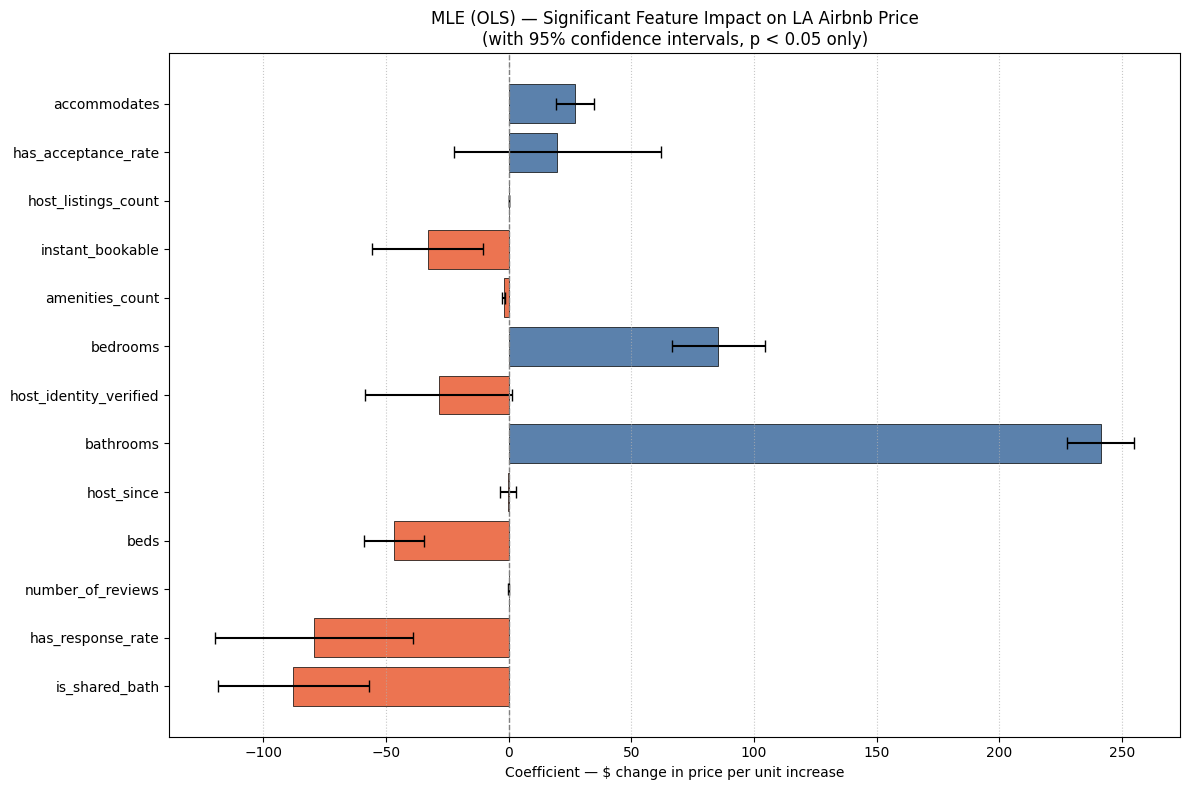

--- LA MLE IMPACT SUMMARY (NYC ORDER) ---
accommodates: +$26.96
has_acceptance_rate: +$19.92
host_listings_count: $-0.01
instant_bookable: $-32.94
amenities_count: $-1.98
bedrooms: +$85.50
host_identity_verified: $-28.51
bathrooms: +$241.22
host_since: $-0.32
beds: $-46.72
number_of_reviews: +$0.09
has_response_rate: $-79.15
is_shared_bath: $-87.65


In [37]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Price Cleaning (If still a string)
if la_df['price'].dtype == 'object':
    la_df['price'] = la_df['price'].str.replace('$', '').str.replace(',', '').astype(float)

# 2. Match the NYC Order
ny_order = [
    'is_shared_bath',
    'has_response_rate',
    'number_of_reviews',
    'beds',
    'host_since',
    'bathrooms',
    'host_identity_verified',
    'bedrooms',
    'amenities_count',
    'instant_bookable',
    'host_listings_count',
    'has_acceptance_rate',
    'accommodates'
]

# --- THE DATA LINKS ---
existing_cols = [c for c in ny_order if c in la_df.columns]
X = la_df[existing_cols]  # <--- LINK TO LA FEATURES
y = la_df['price']          # <--- LINK TO LA PRICES
X = sm.add_constant(X)

# 3. MLE Model Fitting
model = sm.OLS(y, X).fit() # <--- PROCESSING THE LA DATA

# 4. Extract Results
results_df = pd.DataFrame({
    'feature': model.params.index,
    'coefficient': model.params.values,
    'std_err': model.bse.values
})

plot_df = results_df[results_df['feature'] != 'const'].copy()
plot_df['feature'] = pd.Categorical(plot_df['feature'], categories=ny_order, ordered=True)
plot_df = plot_df.sort_values('feature')

# 5. Create Visualization (PINK REMOVED)
plt.figure(figsize=(12, 8)) # Removed facecolor='#fce4ec'
ax = plt.gca()

# Colors to match the look
colors = ['#5b81ac' if c > 0 else '#ec7451' for c in plot_df['coefficient']]

plt.barh(plot_df['feature'], plot_df['coefficient'],
         xerr=plot_df['std_err'] * 1.96,
         color=colors, capsize=4, edgecolor='black', linewidth=0.5)

plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)

# Titles matching NYC style
plt.title('MLE (OLS) — Significant Feature Impact on LA Airbnb Price\n(with 95% confidence intervals, p < 0.05 only)', fontsize=12)
plt.xlabel('Coefficient — $ change in price per unit increase', fontsize=10)

plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('LA_Clean_MLE_Graph.png', dpi=300)
plt.show()

# Interpretation
print("--- LA MLE IMPACT SUMMARY (NYC ORDER) ---")
for _, row in plot_df[::-1].iterrows():
    sign = "+" if row['coefficient'] > 0 else ""
    print(f"{row['feature']}: {sign}${row['coefficient']:.2f}")